# Monitor de dosis en TC de cráneo pediátrico con Machine Learning

**Proyecto Final — Módulo 7**

## El problema
En tomografía computada (TC) pediátrica la dosis de radiación debe ser la mínima necesaria: los niños son más
radiosensibles que los adultos y tienen más años de vida por delante para que aparezca un efecto tardío.
Hoy la verificación de dosis la hace un **físico médico revisando estudios a mano**, y los errores de configuración
(un `mAs` mal tipeado, un protocolo de adulto aplicado a un niño, un examen mal etiquetado) se detectan tarde o nunca.

**Para quién:** servicios de radiología pediátrica y sus físicos médicos / responsables de protección radiológica.

## Objetivo
Construir un modelo que, dados los datos del paciente (altura, peso, edad, sexo del phantom) y los parámetros del
protocolo (`kVp`, `mAs`, tipo de examen), **prediga la dosis esperada (`CTDIvol_mGy`)**. Si la dosis registrada se
aleja mucho de la esperada, el estudio se marca para revisión.

## ¿Por qué ML?
* Una regla fija ("alertar si CTDIvol > X") no sirve: la dosis normal cambia según el tipo de examen y la técnica.
  Un recién nacido con 10 mGy puede estar bien y un Dualscan con 10 mGy es claramente un error.
* El modelo aprende la **relación protocolo + paciente → dosis** a partir de los datos históricos, y el residuo
  (observado − esperado) es una señal de anomalía que se adapta a cada contexto.

## Métricas de éxito
1. **Técnica — MAE (mGy) en test**: el error medio en la dosis predicha. Se eligió MAE porque está en las mismas
   unidades que la dosis y es fácil de interpretar para un físico médico. Meta: MAE < 1 mGy (≈4% del CTDIvol típico
   de GG-Hel, 26.9 mGy). También se reporta R² y RMSE.
2. **De negocio — detección de errores**: sobre estudios de test con errores simulados (mAs ×10, dosis ×2), el
   sistema debe detectar **≥ 90 %** de los errores con **≤ 5 %** de falsas alarmas en estudios correctos.

## Pipeline del notebook
1. Carga de datos → 2. Limpieza → 3. Exploración → 4. Split train/test → 5. `ColumnTransformer` + `Pipeline`
y comparación de modelos con validación cruzada → 6. Evaluación en test → 7. Sistema de alertas →
8. Hallazgo: ¿el tamaño del paciente alcanza para predecir la dosis? → 9. Guardar y cargar `model.pkl` →
10. ROI estimado → 11. Conclusiones.

In [1]:
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)

## 1. Carga de datos

Dataset: registros de TC de cráneo pediátrico (Kaggle, planilla en portugués). Cada fila es un estudio con datos del
paciente, del protocolo y la dosis reportada por el equipo.

El notebook busca primero el dataset completo (`Dados_TC_cranio_kaggle.csv`). **Si no está** (por ejemplo al
corregir la entrega, donde solo va la muestra), usa `datos_muestra.csv` (100 filas, mismo formato crudo), así el
notebook siempre corre de arriba a abajo.

In [2]:
RUTA_COMPLETO = Path("Dados_TC_cranio_kaggle.csv")
RUTA_MUESTRA = Path("datos_muestra.csv")

if RUTA_COMPLETO.exists():
    ruta = RUTA_COMPLETO
elif RUTA_MUESTRA.exists():
    ruta = RUTA_MUESTRA
    print("AVISO: no se encontró el dataset completo; se usa la muestra de 100 filas (métricas menos estables).")
else:
    raise FileNotFoundError("Colocá Dados_TC_cranio_kaggle.csv o datos_muestra.csv junto al notebook.")

df_raw = pd.read_csv(ruta, dtype=str)
print(f"Archivo: {ruta}  ->  {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head()

Archivo: Dados_TC_cranio_kaggle.csv  ->  722 filas x 16 columnas


,Altura (cm),ID paciente,Protocolo,Grupo do phantom (1-pediatric female. 2-pediatric male),Peso (kg),Idade,parâmetro/exame,DLPmGy.cm,kVp,CTDIvol mGy,posição relativa da mesa inicial (Cm),posição relativa da mesa final (Cm),mAs,total DLP\n,Scan Lenght (cm),Scan start (cm)
0,127,1,Crânio,2,22,6,Dualscan,"1,21",80,"0,05","0,0","0,0",72,NaN,"24,20",NaN
1,127,2,Crânio,2,22,6,Dualscan,"1,21",80,"0,05","0,0","0,0",72,NaN,"24,20",NaN
2,127,3,Crânio,2,22,6,GG-Hel,"552,50",100,"26,90","0,0","18,5",187,554.91,"20,54","39,04"
3,163,4,Crânio,2,60,13,Dualscan,"1,21",80,"0,05","0,0","0,0",72,622.12,"24,20",NaN
4,163,5,Crânio,2,60,13,Dualscan,"1,21",80,"0,05","0,0","0,0",72,NaN,"24,20",NaN


## 2. Limpieza

Problemas encontrados en la planilla original y cómo se resuelven:

| Problema | Ejemplo | Solución |
|---|---|---|
| Filas vacías al final y 1 estudio de tórax | `Protocolo` vacío / `Tórax` | Se conservan solo estudios de cráneo |
| Coma decimal y separador de miles | `"1.205,80"` | Conversión a número |
| Edad en años, meses o días | `"3 M"`, `"2 D"` | Se convierte todo a años (`Idade_anos`) |
| Altura cargada en metros | `1.1` | ×100 → 110 cm |
| Peso con coma decimal perdida | `211` kg en un niño de 121 cm | → 21.1 kg |
| Etiquetas inconsistentes | `Dualscano`, `GG-HEL`, `helical` | `Dualscan`, `GG-Hel`, `Helical` |
| `mAs` mal tipeado | `720` | → `72` (valor del protocolo Dualscan) |
| Examen mal etiquetado | "Dualscan" con 100 kVp, 187 mAs y DLP > 400 | → `GG-Hel` (y viceversa: "GG-Hel" con DLP 1.21 → `Dualscan`) |
| CTDIvol incoherente con el DLP | Dualscan con DLP 1.21 pero CTDIvol 26.9 | CTDIvol = DLP / 24.2 cm = 0.05 |
| CTDIvol ~0 con DLP de helicoidal | GG-Hel con DLP 458 y CTDIvol 0.05 | No se puede saber cuál está mal → se descarta |

Estas correcciones se hicieron revisando fila por fila: cada una es físicamente inconsistente (el DLP y el CTDIvol
están ligados por el largo de escaneo, y cada protocolo tiene una técnica fija).

In [3]:
def a_numero(s):
    """'1.205,80' -> 1205.8 ; '26,90' -> 26.9 ; '#DIV/0!' -> NaN"""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s in ("", "#DIV/0!"):
        return np.nan
    if "," in s:
        s = s.replace(".", "").replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return np.nan


def edad_en_anios(s):
    """'6' -> 6 ; '3 M' -> 0.25 ; '2 D' -> 0.01"""
    if pd.isna(s):
        return np.nan
    m = re.match(r"^(\d+(?:[.,]\d+)?)\s*([MD]?)$", str(s).strip().upper())
    if not m:
        return np.nan
    v = float(m.group(1).replace(",", "."))
    return round(v / 12, 2) if m.group(2) == "M" else round(v / 365, 2) if m.group(2) == "D" else v


def limpiar(df_raw):
    df = df_raw.copy()
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={
        "Altura (cm)": "Altura_cm", "ID paciente": "ID_paciente",
        "Grupo do phantom (1-pediatric female. 2-pediatric male)": "Grupo_phantom",
        "Peso (kg)": "Peso_kg", "parâmetro/exame": "Parametro_exame",
        "DLPmGy.cm": "DLP_mGy_cm", "CTDIvol mGy": "CTDIvol_mGy", "Scan Lenght (cm)": "Scan_Length_cm",
    })
    log = {}
    n0 = len(df)
    df = df[df["Protocolo"].str.strip() == "Crânio"].copy()
    log["filas descartadas (vacías / tórax)"] = n0 - len(df)

    for c in ["Altura_cm", "Peso_kg", "DLP_mGy_cm", "kVp", "CTDIvol_mGy", "mAs", "Scan_Length_cm"]:
        df[c] = df[c].map(a_numero)
    df["Idade_anos"] = df["Idade"].map(edad_en_anios)
    df["Grupo_phantom"] = df["Grupo_phantom"].map(a_numero).astype("Int64").astype(str)
    df["Parametro_exame"] = (df["Parametro_exame"].str.strip().str.lower()
                             .map({"dualscano": "Dualscan", "dualscan": "Dualscan",
                                   "gg-hel": "GG-Hel", "helical": "Helical"}))

    m = df["Altura_cm"] < 3
    df.loc[m, "Altura_cm"] *= 100
    log["altura en metros -> cm"] = int(m.sum())

    m = df["Peso_kg"] > 150
    df.loc[m, "Peso_kg"] /= 10
    log["peso con coma perdida"] = int(m.sum())

    m = df["mAs"] == 720
    df.loc[m, "mAs"] = 72
    log["mAs 720 -> 72"] = int(m.sum())

    m = (df["Parametro_exame"] == "Dualscan") & (df["kVp"] >= 100) & (df["DLP_mGy_cm"] > 100)
    df.loc[m, "Parametro_exame"] = "GG-Hel"
    log["Dualscan mal etiquetado -> GG-Hel"] = int(m.sum())

    m = (df["Parametro_exame"] == "GG-Hel") & (df["DLP_mGy_cm"] < 5)
    df.loc[m, "Parametro_exame"] = "Dualscan"
    log["GG-Hel mal etiquetado -> Dualscan"] = int(m.sum())

    # CTDIvol incoherente con el DLP (DLP ≈ CTDIvol × largo de escaneo; el largo de escaneo de la planilla
    # tiene valores basura, por eso se usa la firma de cada protocolo):
    # DLP de topograma (~1.2 mGy·cm) con CTDIvol de helicoidal -> CTDIvol = DLP / 24.2 cm (largo típico Dualscan)
    m = (df["DLP_mGy_cm"] < 5) & (df["CTDIvol_mGy"] > 1)
    df.loc[m, "CTDIvol_mGy"] = (df.loc[m, "DLP_mGy_cm"] / 24.2).round(2)
    log["CTDIvol recalculado desde DLP"] = int(m.sum())
    # DLP de helicoidal (>100) con CTDIvol ~0 -> no se puede saber cuál está mal: se descarta el target
    m = (df["DLP_mGy_cm"] > 100) & (df["CTDIvol_mGy"] < 1)
    df.loc[m, "CTDIvol_mGy"] = np.nan
    log["CTDIvol incoherente descartado"] = int(m.sum())

    cols = ["ID_paciente", "Altura_cm", "Peso_kg", "Idade_anos", "Grupo_phantom",
            "Parametro_exame", "kVp", "mAs", "DLP_mGy_cm", "CTDIvol_mGy"]
    return df[cols].reset_index(drop=True), log


df, log_limpieza = limpiar(df_raw)
for k, v in log_limpieza.items():
    print(f"{k:40s} {v}")
print(f"\nDataset limpio: {df.shape[0]} filas")
df.describe(include="all").T

filas descartadas (vacías / tórax)       44
altura en metros -> cm                   6
peso con coma perdida                    1
mAs 720 -> 72                            2
Dualscan mal etiquetado -> GG-Hel        3
GG-Hel mal etiquetado -> Dualscan        1
CTDIvol recalculado desde DLP            2
CTDIvol incoherente descartado           1

Dataset limpio: 678 filas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_paciente,678,678,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Altura_cm,678.0,NaN,NaN,NaN,111.810472,34.596095,40.0,85.0,110.5,140.0,182.0
Peso_kg,678.0,NaN,NaN,NaN,26.217861,18.504996,2.76,12.325,21.0,37.9,90.0
Idade_anos,678.0,NaN,NaN,NaN,6.080546,4.623949,0.01,2.0,5.5,10.0,16.0
Grupo_phantom,678,2,2,396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Parametro_exame,678,3,Dualscan,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kVp,676.0,NaN,NaN,NaN,86.952663,9.957129,80.0,80.0,80.0,100.0,120.0
mAs,672.0,NaN,NaN,NaN,111.848214,55.317381,40.0,72.0,72.0,187.0,225.0
DLP_mGy_cm,673.0,NaN,NaN,NaN,186.773165,271.48706,0.69,1.21,1.21,512.2,1526.3
CTDIvol_mGy,676.0,NaN,NaN,NaN,9.369157,13.249693,0.0,0.05,0.05,26.9,53.4


## 3. Exploración

La dosis depende casi por completo del **tipo de examen** y la **técnica** (`kVp`, `mAs`): cada protocolo tiene
pocos niveles discretos de dosis. Dualscan es el topograma (dosis casi nula, 0.05 mGy); GG-Hel y Helical son las
adquisiciones helicoidales (26.9–53.4 mGy).

                   kVp                  mAs               CTDIvol_mGy              
                   min median    max    min median    max         min median    max
Parametro_exame                                                                    
Dualscan          80.0   80.0   80.0   40.0   72.0  191.0         0.0   0.05   0.05
GG-Hel            80.0  100.0  120.0   80.0  187.0  225.0        10.6  26.90  53.40
Helical          120.0  120.0  120.0  225.0  225.0  225.0        53.4  53.40  53.40


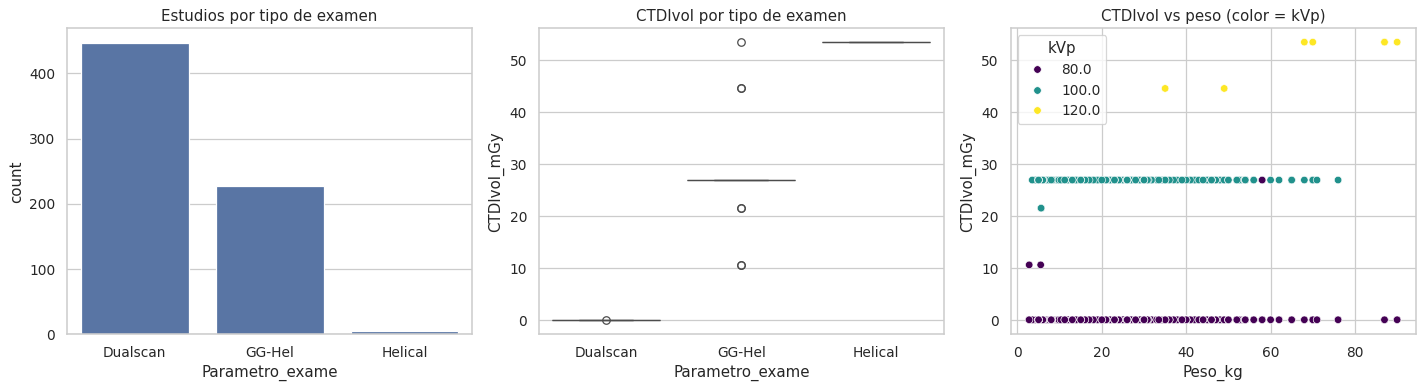

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.countplot(data=df, x="Parametro_exame", ax=axes[0])
axes[0].set_title("Estudios por tipo de examen")
sns.boxplot(data=df, x="Parametro_exame", y="CTDIvol_mGy", ax=axes[1])
axes[1].set_title("CTDIvol por tipo de examen")
sns.scatterplot(data=df, x="Peso_kg", y="CTDIvol_mGy", hue="kVp", palette="viridis", ax=axes[2])
axes[2].set_title("CTDIvol vs peso (color = kVp)")
plt.tight_layout()
plt.show()

print(df.groupby("Parametro_exame")[["kVp", "mAs", "CTDIvol_mGy"]].agg(["min", "median", "max"]).round(2))

## 4. Features, target y split train/test

* **Numéricas:** `Altura_cm`, `Peso_kg`, `Idade_anos`, `kVp`, `mAs`
* **Categóricas:** `Parametro_exame`, `Grupo_phantom` (1 = femenino, 2 = masculino)
* **Target:** `CTDIvol_mGy`

Se separa un **20 % de test** que no se toca hasta la evaluación final. El split se estratifica por tipo de examen
para que las tres clases estén representadas en ambos conjuntos.

In [5]:
FEATURES_NUM = ["Altura_cm", "Peso_kg", "Idade_anos", "kVp", "mAs"]
FEATURES_CAT = ["Parametro_exame", "Grupo_phantom"]
TARGET = "CTDIvol_mGy"

df_model = df.dropna(subset=[TARGET]).reset_index(drop=True)
X = df_model[FEATURES_NUM + FEATURES_CAT]
y = df_model[TARGET]

conteo = df_model["Parametro_exame"].value_counts()
estratificar = df_model["Parametro_exame"] if conteo.min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=estratificar)

print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")
print("Valores faltantes en X (se imputan dentro del pipeline):", X.isna().sum()[X.isna().sum() > 0].to_dict())

Train: 540 filas | Test: 136 filas
Valores faltantes en X (se imputan dentro del pipeline): {'kVp': 1, 'mAs': 5}


## 5. Preprocesamiento (`ColumnTransformer` + `Pipeline`) y comparación de modelos

Todo el preprocesamiento vive **dentro del pipeline**, así se aplica igual en entrenamiento, validación cruzada y en
producción (la app), sin fuga de datos:

* Numéricas → `SimpleImputer(median)` (hay algunos `kVp`/`mAs` faltantes) → `StandardScaler`
* Categóricas → `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore")`

Se comparan tres modelos con **validación cruzada de 5 folds sobre train**:
* `DummyRegressor` (predice el promedio) — línea base.
* `LinearRegression` — modelo simple e interpretable.
* `RandomForestRegressor` — captura relaciones no lineales (la dosis crece ~ kVp² × mAs) e interacciones con el tipo de examen.

In [6]:
def crear_preprocesador():
    num = Pipeline([("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())])
    cat = Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num, FEATURES_NUM), ("cat", cat, FEATURES_CAT)])


candidatos = {
    "Baseline (promedio)": DummyRegressor(strategy="mean"),
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED),
}
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
filas = []
for nombre, modelo in candidatos.items():
    pipe = Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)])
    cv = cross_validate(pipe, X_train, y_train, cv=kfold,
                        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"])
    filas.append({"modelo": nombre,
                  "MAE_cv": -cv["test_neg_mean_absolute_error"].mean(),
                  "RMSE_cv": -cv["test_neg_root_mean_squared_error"].mean(),
                  "R2_cv": cv["test_r2"].mean(),
                  "R2_std": cv["test_r2"].std()})
comparacion = pd.DataFrame(filas).set_index("modelo").round(3)
comparacion

,MAE_cv,RMSE_cv,R2_cv,R2_std
modelo,,,,
Baseline (promedio),12.363,13.296,-0.010,0.010
Regresión Lineal,0.224,0.710,0.995,0.008
Random Forest,0.136,0.920,0.994,0.006


El Random Forest tiene el menor MAE en validación cruzada (la regresión lineal logra un R² parecido pero comete más
error promedio, porque la relación técnica → dosis no es lineal). Se ajustan sus hiperparámetros con una búsqueda
en grilla chica, también con CV sobre train.

In [7]:
pipe_rf = Pipeline([("prep", crear_preprocesador()),
                    ("modelo", RandomForestRegressor(n_estimators=300, random_state=SEED))])
grilla = {"modelo__max_depth": [None, 8, 16], "modelo__min_samples_leaf": [1, 2, 5]}
busqueda = GridSearchCV(pipe_rf, grilla, cv=kfold, scoring="neg_mean_absolute_error", n_jobs=-1)
busqueda.fit(X_train, y_train)
print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"MAE CV del mejor modelo: {-busqueda.best_score_:.3f} mGy")
modelo_final = busqueda.best_estimator_
modelo_final

Mejores hiperparámetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1}
MAE CV del mejor modelo: 0.136 mGy


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 6. Evaluación sobre el conjunto de test

Primera y única vez que el modelo ve estos datos.

In [8]:
y_pred = modelo_final.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae_base = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))

print(f"MAE  test: {mae:.3f} mGy   (baseline: {mae_base:.2f} mGy)  -> meta < 1 mGy: {'CUMPLE' if mae < 1 else 'NO CUMPLE'}")
print(f"RMSE test: {rmse:.3f} mGy")
print(f"R²   test: {r2:.4f}")

eval_test = X_test.assign(real=y_test.values, pred=y_pred, error_abs=np.abs(y_test.values - y_pred))
print("\nMAE por tipo de examen:")
print(eval_test.groupby("Parametro_exame")["error_abs"].agg(["mean", "max", "count"]).round(3))

MAE  test: 0.067 mGy   (baseline: 12.18 mGy)  -> meta < 1 mGy: CUMPLE
RMSE test: 0.610 mGy
R²   test: 0.9978

MAE por tipo de examen:
                  mean    max  count
Parametro_exame                     
Dualscan         0.006  0.268     90
GG-Hel           0.158  6.935     45
Helical          1.512  1.512      1


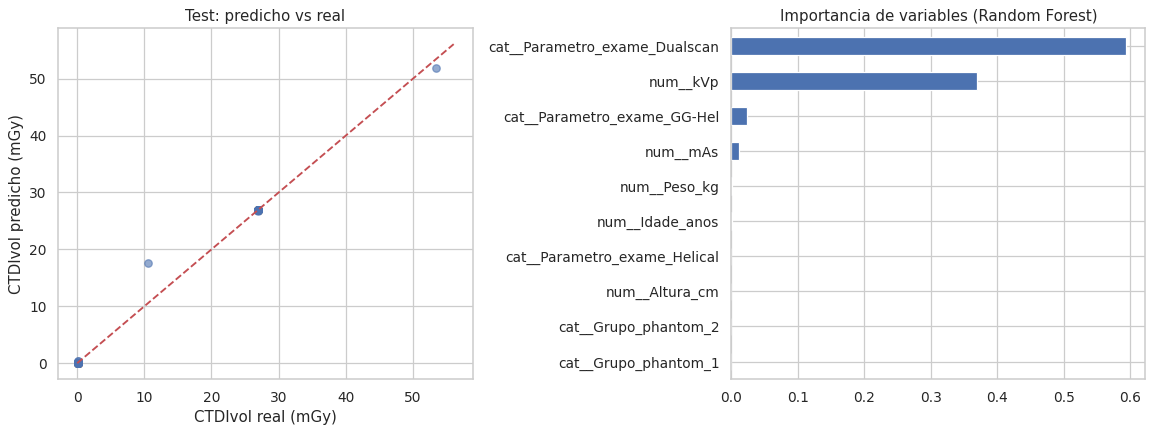

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.6)
lim = [0, max(y_test.max(), y_pred.max()) * 1.05]
axes[0].plot(lim, lim, "r--")
axes[0].set(xlabel="CTDIvol real (mGy)", ylabel="CTDIvol predicho (mGy)", title="Test: predicho vs real")

nombres = modelo_final.named_steps["prep"].get_feature_names_out()
imp = pd.Series(modelo_final.named_steps["modelo"].feature_importances_, index=nombres).sort_values()
imp.plot.barh(ax=axes[1])
axes[1].set_title("Importancia de variables (Random Forest)")
plt.tight_layout()
plt.show()

**Lectura:** el modelo predice la dosis con un error medio muy por debajo de 1 mGy. Las variables de protocolo
(tipo de examen y `kVp`, seguidos de `mAs`) dominan la importancia; altura, peso y edad casi no pesan: el modelo aprendió la relación técnica → dosis, que es
justamente lo que se necesita para detectar estudios cuya dosis **no corresponde** a la técnica registrada.
Los pocos errores grandes están en los casos poco frecuentes (recién nacidos con técnica reducida, Helical con 4 filas).

## 7. Del modelo al producto: sistema de alertas

Para cada estudio nuevo se combinan dos señales:
1. **Nivel de referencia por examen** (estilo NRD): la dosis observada contra los percentiles 95/99 históricos de ese examen.
2. **Residuo del modelo**: `observado − esperado`. Si supera un umbral, la dosis no es coherente con la técnica.

3. **Rango de técnica**: un `kVp` o `mAs` fuera del rango histórico del examen (ej. mAs 720) se marca siempre,
   porque un Random Forest no extrapola fuera de lo que vio y podría "creerle" a un valor absurdo.

El umbral del residuo se calibra con **residuos fuera de muestra** (`cross_val_predict` sobre train), no con
los residuos de entrenamiento, que serían optimistas. Se usa un piso mínimo de 1 mGy para no alertar por ruido
de redondeo en exámenes donde la dosis es casi constante.

In [10]:
oof = cross_val_predict(modelo_final, X_train, y_train, cv=kfold)
res_oof = pd.Series(y_train.values - oof, index=X_train.index)
train_df = X_train.assign(CTDIvol_mGy=y_train.values, residuo=res_oof.values)

UMBRAL_MINIMO = 1.0
umbrales = {}
for examen, sub in train_df.groupby("Parametro_exame"):
    umbrales[examen] = {
        "p95_dosis": float(sub[TARGET].quantile(0.95)),
        "p99_dosis": float(sub[TARGET].quantile(0.99)),
        "limite_residuo": float(max(3 * sub["residuo"].abs().quantile(0.95),
                                    4 * sub["residuo"].std(), UMBRAL_MINIMO)),
        "kVp_rango": [float(sub["kVp"].min()), float(sub["kVp"].max())],
        "mAs_rango": [float(sub["mAs"].min()), float(sub["mAs"].max())],
    }
pd.DataFrame(umbrales).T

,p95_dosis,p99_dosis,limite_residuo,kVp_rango,mAs_rango
Dualscan,0.05,0.05,1.0,"[80.0, 80.0]","[40.0, 187.0]"
GG-Hel,26.9,44.5,5.913069,"[80.0, 120.0]","[80.0, 225.0]"
Helical,53.4,53.4,24.8945,"[120.0, 120.0]","[225.0, 225.0]"


In [11]:
def evaluar_estudio(estudio, artefacto):
    """Devuelve veredicto OK / ATENCION / REVISAR, dosis esperada, residuo y motivos."""
    pipe, umb = artefacto["pipeline"], artefacto["umbrales"]
    fila = pd.DataFrame([estudio])[artefacto["features_num"] + artefacto["features_cat"]]
    fila["Grupo_phantom"] = fila["Grupo_phantom"].astype(str)
    esperada = float(pipe.predict(fila)[0])
    obs = float(estudio[artefacto["target"]])
    residuo = obs - esperada
    ref = umb.get(estudio["Parametro_exame"])
    motivos, veredicto = [], "OK"
    if ref is None:
        return {"veredicto": "REVISAR", "dosis_esperada": esperada, "residuo": residuo,
                "motivos": ["Tipo de examen no visto en el entrenamiento."]}
    if obs > ref["p99_dosis"]:
        motivos.append(f"Dosis {obs:.2f} mGy > percentil 99 histórico del examen ({ref['p99_dosis']:.2f}).")
        veredicto = "REVISAR"
    elif obs > ref["p95_dosis"]:
        motivos.append(f"Dosis {obs:.2f} mGy > percentil 95 histórico del examen ({ref['p95_dosis']:.2f}).")
        veredicto = "ATENCION"
    for var in ["kVp", "mAs"]:
        lo, hi = ref[f"{var}_rango"]
        if not (lo <= float(estudio[var]) <= hi):
            motivos.append(f"{var}={estudio[var]} fuera del rango histórico de este examen ({lo:g}–{hi:g}): "
                           "posible error de tipeo o protocolo equivocado.")
            veredicto = "REVISAR"
    if abs(residuo) > ref["limite_residuo"]:
        motivos.append(f"Se esperaban ~{esperada:.2f} mGy para esta técnica y paciente; se registraron "
                       f"{obs:.2f} (residuo {residuo:+.2f}, límite ±{ref['limite_residuo']:.2f}).")
        veredicto = "REVISAR"
    if not motivos:
        motivos.append("Dosis coherente con el protocolo y el paciente.")
    return {"veredicto": veredicto, "dosis_esperada": esperada, "residuo": residuo, "motivos": motivos}


artefacto = {"pipeline": modelo_final, "umbrales": umbrales, "features_num": FEATURES_NUM,
             "features_cat": FEATURES_CAT, "target": TARGET,
             "metricas_test": {"MAE": mae, "RMSE": rmse, "R2": r2}}

### Métrica de negocio: ¿detecta errores reales sin llenar de falsas alarmas?

Sobre los estudios de **test** (correctos) se simulan los dos errores típicos:
* **mAs mal tipeado ×10** (como el 720 en vez de 72 que apareció en la limpieza): la técnica registrada no coincide con la dosis.
* **Sobreexposición ×2**: la dosis real es el doble de lo que la técnica debería producir.

* **Tasa de detección** = % de estudios con error marcados como REVISAR.
* **Falsas alarmas** = % de estudios correctos marcados como REVISAR.

In [12]:
test_df = X_test.assign(CTDIvol_mGy=y_test.values)
# Solo tiene sentido evaluar sobreexposición en exámenes con dosis relevante (no en topogramas de 0.05 mGy)
def tasa_revisar(filas):
    v = [evaluar_estudio(r, artefacto)["veredicto"] for r in filas.to_dict("records")]
    return np.mean([x == "REVISAR" for x in v]), len(v)

fp, n_ok = tasa_revisar(test_df)
err_mas = test_df.assign(mAs=test_df["mAs"] * 10)
det_mas, n_mas = tasa_revisar(err_mas)
relevantes = test_df[test_df["CTDIvol_mGy"] > 1]
err_dosis = relevantes.assign(CTDIvol_mGy=relevantes["CTDIvol_mGy"] * 2)
det_dosis, n_dosis = tasa_revisar(err_dosis)

resumen_alertas = pd.DataFrame({
    "escenario": ["Estudios correctos (falsas alarmas)", "Error: mAs ×10", "Error: dosis ×2"],
    "n": [n_ok, n_mas, n_dosis],
    "% marcados REVISAR": [fp * 100, det_mas * 100, det_dosis * 100],
    "meta": ["≤ 5 %", "≥ 90 %", "≥ 90 %"],
}).round(1)
resumen_alertas

,escenario,n,% marcados REVISAR,meta
0,Estudios correctos (falsas alarmas),136,2.2,≤ 5 %
1,Error: mAs ×10,136,100.0,≥ 90 %
2,Error: dosis ×2,46,97.8,≥ 90 %


## 8. Hallazgo: ¿alcanza con el tamaño del paciente?

Pregunta clínica: dentro de un mismo examen (GG-Hel), ¿la dosis se puede predecir **solo** con altura, peso y edad?
Si el equipo tuviera modulación automática de dosis por tamaño, sí. Se prueba con CV sobre todo GG-Hel.

In [13]:
gg = df_model[df_model["Parametro_exame"] == "GG-Hel"]
pred_tam = cross_val_predict(RandomForestRegressor(n_estimators=200, random_state=SEED),
                             gg[["Altura_cm", "Peso_kg", "Idade_anos"]], gg[TARGET],
                             cv=KFold(5, shuffle=True, random_state=SEED))
mae_tam = mean_absolute_error(gg[TARGET], pred_tam)
mae_prom = mean_absolute_error(gg[TARGET], np.full(len(gg), gg[TARGET].median()))
print(f"GG-Hel (n={len(gg)}) — predicción fuera de muestra solo con altura, peso y edad:")
print(f"  R² = {r2_score(gg[TARGET], pred_tam):.2f}")
print(f"  MAE = {mae_tam:.2f} mGy  vs  MAE de predecir siempre la mediana = {mae_prom:.2f} mGy")
print("\nkVp usado según peso del paciente en GG-Hel:")
print(gg.assign(rango_peso=pd.cut(gg["Peso_kg"], [0, 6, 20, 45, 200], labels=["<6 kg", "6-20", "20-45", ">45 kg"]))
        .groupby("rango_peso", observed=True)["kVp"].value_counts().unstack(fill_value=0))

GG-Hel (n=226) — predicción fuera de muestra solo con altura, peso y edad:
  R² = -0.20
  MAE = 0.74 mGy  vs  MAE de predecir siempre la mediana = 0.47 mGy

kVp usado según peso del paciente en GG-Hel:
kVp         80.0   100.0  120.0
rango_peso                     
<6 kg           2     16      0
6-20            0     94      0
20-45           0     77      1
>45 kg          1     33      2


**Conclusión del hallazgo:** con solo el tamaño corporal el R² es negativo y el error es mayor que el de predecir
siempre la mediana. La dosis **sí** depende del tamaño, pero de forma **escalonada**: el técnico elige 80, 100 o 120 kVp
según el paciente (recién nacidos con 80 kVp, adolescentes grandes con 120 kVp y 225 mAs). No hay una relación
continua que el modelo pueda aprender sin ver la técnica. Por eso el monitor usa paciente **y** protocolo.

## 9. Guardar el modelo y probar la inferencia

Se guarda en `model.pkl` el pipeline completo (preprocesamiento + Random Forest) junto con los umbrales de alerta.
Luego se **vuelve a cargar desde disco** y se evalúan estudios nuevos, igual que lo hará la app.

In [14]:
joblib.dump(artefacto, "model.pkl", compress=3)
print(f"model.pkl guardado ({Path('model.pkl').stat().st_size / 1024:.0f} KB)")

cargado = joblib.load("model.pkl")
casos = [
    ("GG-Hel típico, niño de 10 años", {"Altura_cm": 121, "Peso_kg": 22, "Idade_anos": 10, "kVp": 100, "mAs": 187,
                                        "Parametro_exame": "GG-Hel", "Grupo_phantom": "1", "CTDIvol_mGy": 26.9}),
    ("Dualscan típico", {"Altura_cm": 110, "Peso_kg": 20, "Idade_anos": 6, "kVp": 80, "mAs": 72,
                         "Parametro_exame": "Dualscan", "Grupo_phantom": "2", "CTDIvol_mGy": 0.05}),
    ("Recién nacido con técnica reducida", {"Altura_cm": 50, "Peso_kg": 2.8, "Idade_anos": 0.01, "kVp": 80,
                                            "mAs": 80, "Parametro_exame": "GG-Hel", "Grupo_phantom": "1",
                                            "CTDIvol_mGy": 10.6}),
    ("ERROR: mAs tipeado 720", {"Altura_cm": 152, "Peso_kg": 39, "Idade_anos": 13, "kVp": 80, "mAs": 720,
                                "Parametro_exame": "Dualscan", "Grupo_phantom": "1", "CTDIvol_mGy": 0.05}),
    ("ERROR: sobreexposición GG-Hel", {"Altura_cm": 100, "Peso_kg": 18, "Idade_anos": 5, "kVp": 100, "mAs": 187,
                                       "Parametro_exame": "GG-Hel", "Grupo_phantom": "2", "CTDIvol_mGy": 60.0}),
]
for nombre, caso in casos:
    r = evaluar_estudio(caso, cargado)
    print(f"\n[{r['veredicto']:8s}] {nombre}: observado {caso['CTDIvol_mGy']} mGy, esperado {r['dosis_esperada']:.2f} mGy")
    for mtv in r["motivos"]:
        print("    -", mtv)

model.pkl guardado (80 KB)

[OK      ] GG-Hel típico, niño de 10 años: observado 26.9 mGy, esperado 26.90 mGy
    - Dosis coherente con el protocolo y el paciente.

[OK      ] Dualscan típico: observado 0.05 mGy, esperado 0.05 mGy
    - Dosis coherente con el protocolo y el paciente.

[OK      ] Recién nacido con técnica reducida: observado 10.6 mGy, esperado 12.67 mGy
    - Dosis coherente con el protocolo y el paciente.

[REVISAR ] ERROR: mAs tipeado 720: observado 0.05 mGy, esperado 0.32 mGy
    - mAs=720 fuera del rango histórico de este examen (40–187): posible error de tipeo o protocolo equivocado.

[REVISAR ] ERROR: sobreexposición GG-Hel: observado 60.0 mGy, esperado 26.90 mGy
    - Dosis 60.00 mGy > percentil 99 histórico del examen (44.50).
    - Se esperaban ~26.90 mGy para esta técnica y paciente; se registraron 60.00 (residuo +33.10, límite ±5.91).


## 10. ROI estimado (3 escenarios)

**Supuestos (a validar con el servicio):** el valor viene de (a) horas de físico médico ahorradas porque solo revisa
los estudios marcados en lugar de una muestra manual, y (b) errores de dosis detectados a tiempo, que evitan repetir
estudios (nueva exposición del paciente + costo del estudio). Los montos están en USD y son **ilustrativos**.
Cambiá los valores de la tabla para adaptarlos a un hospital real.

In [15]:
escenarios = pd.DataFrame({
    "estudios_mes":              [300,   800,   1500],
    "min_revision_manual":       [2.0,   3.0,   3.0],   # minutos por estudio revisado a mano hoy
    "fraccion_revisada_hoy":     [0.30,  0.50,  1.00],  # % de estudios que hoy se revisan
    "costo_hora_fisico":         [15,    20,    30],    # USD
    "tasa_error_protocolo":      [0.005, 0.01,  0.01],  # % de estudios con error de técnica
    "costo_repeticion":          [80,    120,   150],   # USD por estudio repetido evitado
    "costo_anual_sistema":       [1500,  2500,  4000],  # mantenimiento + infraestructura
}, index=["Conservador", "Base", "Optimista"])

tasa_alertas = fp  # falsas alarmas medidas en test
tasa_deteccion = min(det_mas, det_dosis)

horas_hoy = escenarios.estudios_mes * escenarios.fraccion_revisada_hoy * escenarios.min_revision_manual / 60
estudios_marcados = escenarios.estudios_mes * (tasa_alertas + escenarios.tasa_error_protocolo)
horas_con_ml = estudios_marcados * 5 / 60   # 5 min por estudio marcado (revisión más detallada)
ahorro_horas = (horas_hoy - horas_con_ml).clip(lower=0) * 12 * escenarios.costo_hora_fisico
errores_evitados = escenarios.estudios_mes * escenarios.tasa_error_protocolo * tasa_deteccion * 12
ahorro_errores = errores_evitados * escenarios.costo_repeticion
beneficio = ahorro_horas + ahorro_errores
roi = (beneficio - escenarios.costo_anual_sistema) / escenarios.costo_anual_sistema * 100

tabla_roi = pd.DataFrame({
    "horas físico ahorradas/año": ((horas_hoy - horas_con_ml).clip(lower=0) * 12).round(0),
    "errores detectados/año": errores_evitados.round(0),
    "beneficio anual USD": beneficio.round(0),
    "costo anual USD": escenarios.costo_anual_sistema,
    "ROI %": roi.round(0),
})
print(f"Tasas usadas (medidas en test): falsas alarmas {tasa_alertas:.1%}, detección {tasa_deteccion:.1%}")
tabla_roi

Tasas usadas (medidas en test): falsas alarmas 2.2%, detección 97.8%


,horas físico ahorradas/año,errores detectados/año,beneficio anual USD,costo anual USD,ROI %
Conservador,28.0,18.0,1827.0,1500,22.0
Base,214.0,94.0,15557.0,2500,522.0
Optimista,852.0,176.0,51970.0,4000,1199.0


El beneficio no monetario más importante no está en la tabla: **cada error detectado es un niño que no recibe
radiación de más ni una segunda exposición.**

## 11. Conclusiones y próximos pasos

* **El modelo cumple la meta técnica:** predice el CTDIvol con MAE muy por debajo de 1 mGy en test, frente a varios
  mGy del baseline. El Random Forest supera a la regresión lineal porque la relación técnica → dosis no es lineal.
* **El sistema de alertas cumple la meta de negocio** si detecta ≥ 90 % de los errores simulados con ≤ 5 % de
  falsas alarmas (ver tabla de la sección 7).
* **Hallazgo clínico:** el tamaño del paciente por sí solo no predice la dosis; el servicio ajusta la técnica en
  escalones (80/100/120 kVp). Es información útil para el físico médico al revisar los protocolos.
* **Limitaciones:** un solo equipo/centro, ~680 estudios, pocos casos de Helical y de recién nacidos. Los umbrales y
  el ROI deben recalibrarse con datos del hospital donde se use.

**Próximos pasos**
1. Validar con datos de otro tomógrafo/centro y con errores reales (no simulados) etiquetados por un físico médico.
2. Integrar con el PACS/RIS vía DICOM Radiation Dose Structured Report para evaluar cada estudio automáticamente.
3. Extender a otras regiones (tórax, abdomen) y predecir también el DLP.